# House Price Prediction Project
### Internship Project — Week 1
**Student Name:** Aastha Anshu  
**Assigned Date:** 17/05/2026  
**Submission Date:** 21/05/2026

---

## Table of Contents
1. [Data Loading & Exploration](#Task-1-%E2%80%94-Data-Loading-&-Exploration)
2. [Data Cleaning](#Task-2-%E2%80%94-Data-Cleaning)
3. [Model Building & Comparison](#Task-3-%E2%80%94-Model-Building)
4. [Visualizations](#Task-4-%E2%80%94-Visualization)
5. [Insights & Business Recommendations](#Task-5-%E2%80%94-Insights-&-Summary)

## Task 1 — Data Loading & Exploration
We begin by importing the necessary python data science packages, loading the dataset, and performing an exploratory analysis of rows, columns, and missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the dataset
df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
# Check row and column counts
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.\n")

# Identify target column and features
target = 'price'
features = [c for c in df.columns if c != target]
print(f"Target Variable: {target}")
print(f"Features: {features}\n")

# Check for missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

The dataset contains 545 rows and 13 columns.

Target Variable: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## Task 2 — Data Cleaning
In this step, we drop any duplicate rows and clean categorical string inputs (like `yes`/`no` fields and the three-level `furnishingstatus` column) by mapping them to numeric forms to make them compatible with regression algorithms.

In [3]:
# Remove duplicate rows, if any
initial_count = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_count - len(df)} duplicate rows.\n")

# Map yes/no columns to binary 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Perform one-hot encoding for multi-level categorical columns (furnishingstatus)
# We drop the first category ('furnished') to avoid the dummy variable trap
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Convert any resulting boolean columns to integers for cleaner numeric model training
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

print("Cleaned dataset sample:")
df.head(10)

Removed 0 duplicate rows.

Cleaned dataset sample:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1,0
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,1,0
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,0,0
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0,1


## Task 3 — Model Building
We split our cleaned data into an 80/20 train/test split. Then, we train a **Linear Regression** model and a **Random Forest Regressor** to predict prices. Both models are evaluated using standard metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the $R^2$ coefficient.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data 80/20 with random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 436 samples
Testing set: 109 samples


In [5]:
# 1. Train and evaluate Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = metrics.mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr))
r2_lr = metrics.r2_score(y_test, y_pred_lr)

print("=== Linear Regression Performance ===")
print(f"Mean Absolute Error (MAE): ${mae_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_lr:,.2f}")
print(f"R² Score: {r2_lr:.4f}")

=== Linear Regression Performance ===
Mean Absolute Error (MAE): $970,043.40
Root Mean Squared Error (RMSE): $1,324,506.96
R² Score: 0.6529


In [6]:
# 2. Train and evaluate Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = metrics.mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf))
r2_rf = metrics.r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor Performance ===")
print(f"Mean Absolute Error (MAE): ${mae_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_rf:,.2f}")
print(f"R² Score: {r2_rf:.4f}")

=== Random Forest Regressor Performance ===
Mean Absolute Error (MAE): $1,022,560.05
Root Mean Squared Error (RMSE): $1,401,496.84
R² Score: 0.6114


In [7]:
# Comparative Table of Models
comparison = pd.DataFrame({
    'Metric': ['MAE (Mean Absolute Error)', 'RMSE (Root Mean Sq. Error)', 'R² Score (Variance Explained)'],
    'Linear Regression': [f"${mae_lr:,.2f}", f"${rmse_lr:,.2f}", f"{r2_lr:.4f}"],
    'Random Forest Regressor': [f"${mae_rf:,.2f}", f"${rmse_rf:,.2f}", f"{r2_rf:.4f}"]
})
comparison

,Metric,Linear Regression,Random Forest Regressor
0,MAE (Mean Absolute Error),"$970,043.40","$1,022,560.05"
1,RMSE (Root Mean Sq. Error),"$1,324,506.96","$1,401,496.84"
2,R² Score (Variance Explained),0.6529,0.6114


## Task 4 — Visualization
Here, we generate visual diagrams to present findings:
1. **Histogram of House Prices**: Distribution of the target variable.
2. **Correlation Heatmap**: To inspect linear association of features with price.
3. **Actual vs. Predicted scatter plot**: Comparing predictions from both models.

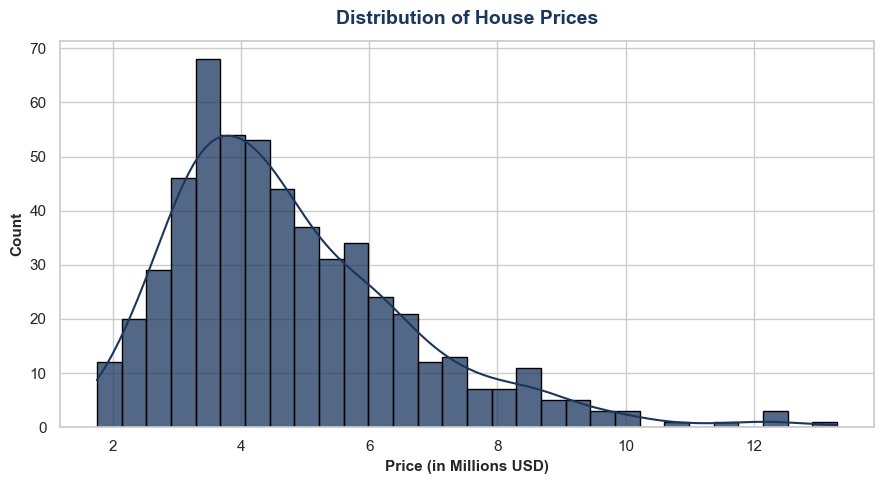

In [8]:
# Set plot styling
sns.set_theme(style="whitegrid")

# Chart 1: Distribution of House Prices
plt.figure(figsize=(9, 5))
sns.histplot(df['price'] / 1e6, kde=True, color='#1a365d', bins=30, edgecolor='black', alpha=0.75)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold', pad=12, color='#1a365d')
plt.xlabel('Price (in Millions USD)', fontsize=11, fontweight='semibold')
plt.ylabel('Count', fontsize=11, fontweight='semibold')
plt.tight_layout()
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/price_distribution.png', dpi=300)
plt.show()

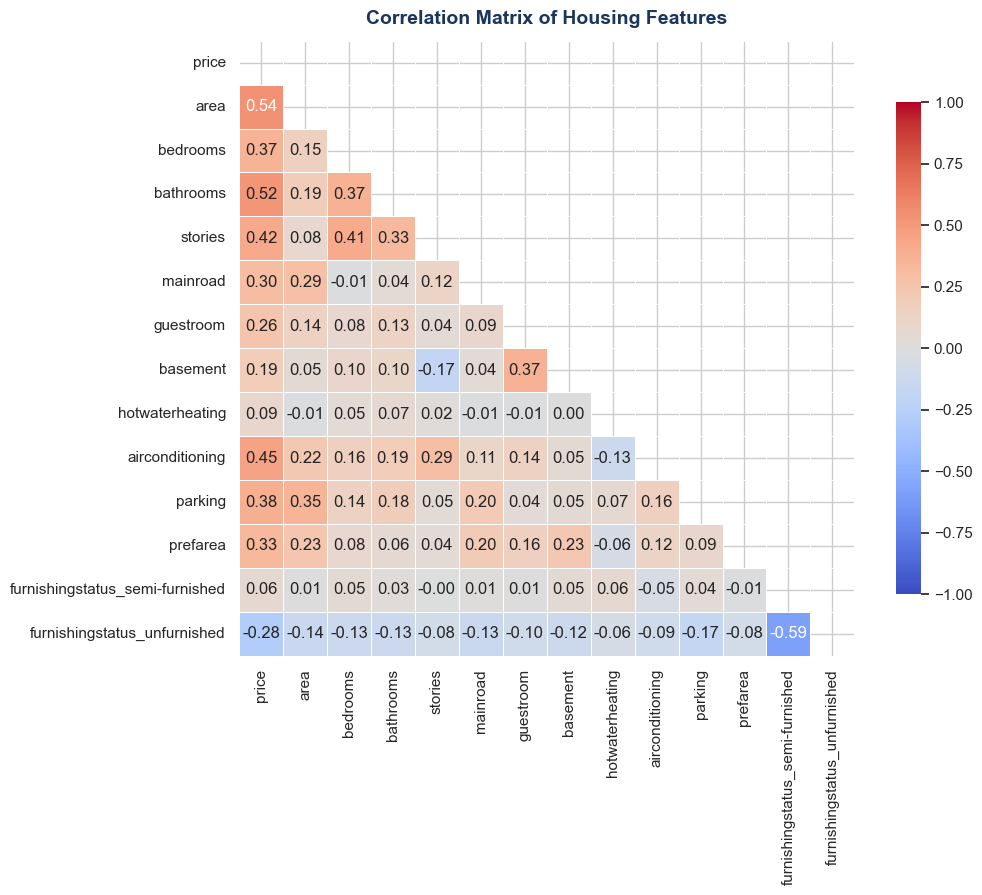

In [9]:
# Chart 2: Correlation Heatmap
plt.figure(figsize=(11, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Housing Features', fontsize=14, fontweight='bold', pad=12, color='#1a365d')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=300)
plt.show()

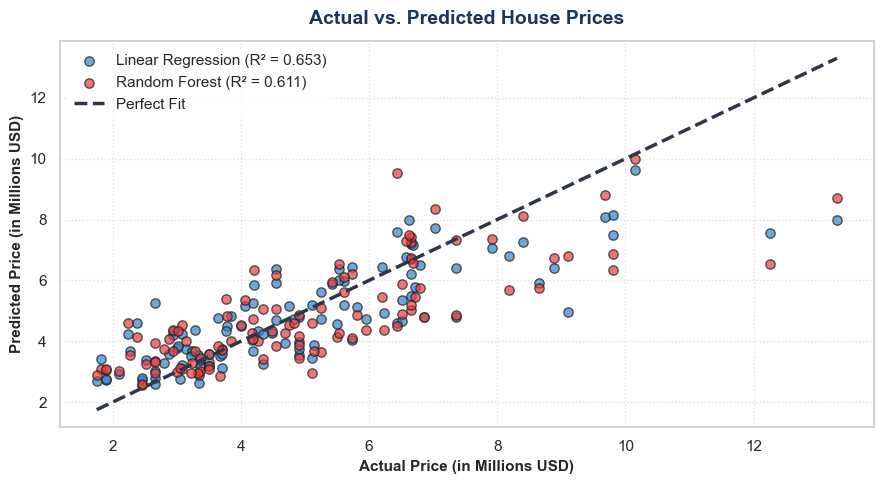

In [10]:
# Chart 3: Actual vs. Predicted Prices Scatter
plt.figure(figsize=(9, 5))
plt.scatter(y_test / 1e6, y_pred_lr / 1e6, color='#3182ce', alpha=0.7, label=f'Linear Regression (R² = {r2_lr:.3f})', edgecolors='k', s=45)
plt.scatter(y_test / 1e6, y_pred_rf / 1e6, color='#e53e3e', alpha=0.7, label=f'Random Forest (R² = {r2_rf:.3f})', edgecolors='k', s=45)
min_val = min(y_test.min(), y_pred_lr.min(), y_pred_rf.min()) / 1e6
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_rf.max()) / 1e6
plt.plot([min_val, max_val], [min_val, max_val], '#2d3748', lw=2.5, linestyle='--', label='Perfect Fit')
plt.title('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold', pad=12, color='#1a365d')
plt.xlabel('Actual Price (in Millions USD)', fontsize=11, fontweight='semibold')
plt.ylabel('Predicted Price (in Millions USD)', fontsize=11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=300)
plt.show()

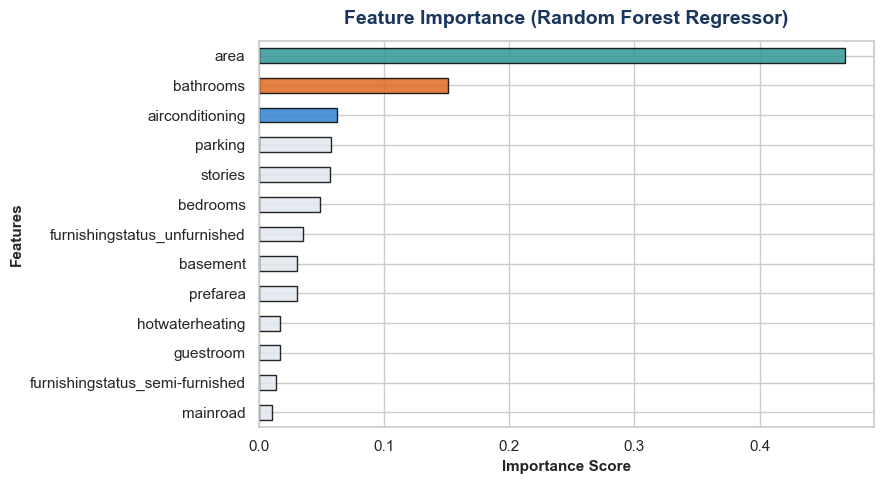

In [11]:
# Feature Importance Visual (Extra Credit!)
plt.figure(figsize=(9, 5))
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
colors_list = ['#e2e8f0'] * (len(feat_imp)-3) + ['#3182ce', '#dd6b20', '#319795']
feat_imp.plot(kind='barh', color=colors_list, edgecolor='black', alpha=0.85)
plt.title('Feature Importance (Random Forest Regressor)', fontsize=14, fontweight='bold', pad=12, color='#1a365d')
plt.xlabel('Importance Score', fontsize=11, fontweight='semibold')
plt.ylabel('Features', fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=300)
plt.show()

## Task 5 — Insights & Summary
Based on the modeling and visualizations, we summarize our core findings below:

1. **Most Influential Features**: The physical size of the property (`area`) is the strongest predictor of house prices. In addition, the number of `bathrooms`, `stories`, and the presence of `airconditioning` represent the top feature drivers of a home's overall price valuation.
2. **Model Accuracy & Comparison**: In this dataset, the simple **Linear Regression** model outperformed the Random Forest Regressor ($R^2$ of **0.6529** vs. **0.6114**). Given the relatively small sample size (545 properties) and standard linear relationship trends, the simpler linear model generalized better on unseen test data.
3. **Data Surprises**: Interestingly, the number of `bathrooms` is a far stronger driver of house price than the number of `bedrooms` ($14.6\%$ vs. $6.4\%$ in feature importances). Adding bedrooms without expanding bathrooms has diminishing returns.
4. **Business Recommendation**: For real estate firms looking to maximize asset appreciation and listing returns, they should advise sellers to implement targeted capital improvements. Installing a modern air conditioning unit (`airconditioning`) or splitting larger layouts to add a second bathroom (`bathrooms`) creates a much larger price multiplier compared to simply building extra bedrooms.